# Parametrized quantum circuits

### Why Do We Need Parameters?

In many quantum algorithms (VQE, QAOA, VQLS), circuits are not fixed — they depend on tunable parameters.

Instead of rebuilding circuits repeatedly, we define:

- **Symbolic parameters** at compile time
- Assign numerical values later

This allows:
- Efficient optimization loops
- Reusable circuit structures
- Hardware execution with late binding

### Creating a Parameter

A `Parameter` is a symbolic variable that can be used inside quantum gates.

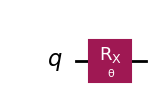

In [29]:
from qiskit.circuit import QuantumCircuit, Parameter

# Create a parameter
theta = Parameter("θ")

qc = QuantumCircuit(1)
qc.rx(theta, 0)

qc.draw("mpl")

In [30]:
print(f"Parameter name: {theta.name}") # parameter name
print(f"Parameter UUID: {theta.uuid}") # parameter unique identifier

Parameter name: θ
Parameter UUID: 388e0641-eb36-4ff5-954b-e47330aee9dd


At this stage:
- The circuit is **not executable**
- It contains symbolic information

The parameter acts like a placeholder.

### Assigning Values to Parameters

Before execution, all parameters must be assigned numerical values.

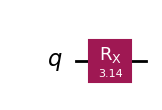

In [ ]:
# Bind parameter
bound_qc = qc.assign_parameters({theta: 3.14, })

bound_qc.draw("mpl")

### Note

- `qc` → symbolic circuit  
- `bound_qc` → executable circuit  

Binding converts symbols → numbers.

### Using Multiple Parameters

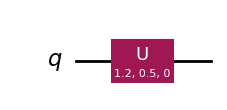

In [7]:
phi = Parameter("φ")
lam = Parameter("λ")

qc = QuantumCircuit(1)
qc.u(phi, lam, 0, 0)

qc.draw("mpl")

# Bind multiple parameters
bound_qc = qc.assign_parameters({phi: 1.2, lam: 0.5})

bound_qc.draw("mpl")

### Parameter Expressions

Parameters can form symbolic expressions. Qiskit's Parameter objects support standard Python arithmetic operations, which automatically create  `ParameterExpression` objects. No special constructor is needed.

<class 'qiskit._accelerate.circuit.ParameterExpression'>


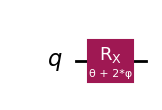

In [33]:
theta = Parameter("θ")
phi = Parameter("φ")

expr = theta + 2 * phi
print(type(expr))

qc = QuantumCircuit(1)
qc.rx(expr, 0)

qc.draw("mpl")

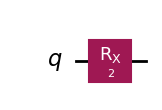

In [ ]:
bound_qc = qc.assign_parameters({theta: 1.0, phi: 0.5}) # NOTE: assign_parameters is a quantum circuit method that binds parameters to specific values, it does not work on Gate

bound_qc.draw("mpl")

### Inspecting Parameters

In [10]:
theta = Parameter("θ")
expr = theta + 1

print("Parameters in expression:", expr.parameters)
print("Number of parameters:", expr.num_parameters)

Parameters in expression: {Parameter(θ)}
Number of parameters: 1


### Gradient of Parameter Expressions

We can compute symbolic derivatives of parameter expressions.

In [11]:
theta = Parameter("θ")
expr = theta**2 + 2*theta

grad = expr.gradient(theta)

print("Expression:", expr)
print("Gradient:", grad)

Expression: 2*θ + θ**2
Gradient: 2 + 2*θ**1


### Substitution

In [12]:
theta = Parameter("θ")
phi = Parameter("φ")

expr = theta + phi

new_expr = expr.subs({phi: 2*theta})

print("Original:", expr)
print("After substitution:", new_expr)

Original: θ + φ
After substitution: 3*θ


## Advanced ParameterExpression Operations

Qiskit `Parameter` objects form symbolic expressions (`ParameterExpression`).

Unlike simple placeholders, they support:
- Mathematical functions (cos, sin, log, exp)
- Symbolic manipulation
- Multiple ways of binding values

This is especially useful in variational algorithms and analytical circuit construction.

In [2]:
from qiskit.circuit import Parameter
import numpy as np

theta = Parameter("θ")
phi = Parameter("φ")

expr_cos = (theta + phi).cos()
expr_sin = theta.sin()
expr_tan = (2 * theta).arctan()

expr_log = (theta + 1).log()
expr_exp = theta.exp()

print("cos expression:", expr_cos)
print("sin expression:", expr_sin)
print("tan expression:", expr_tan)
print("log expression:", expr_log)
print("exp expression:", expr_exp)

cos expression: cos(θ + φ)
sin expression: sin(θ)
tan expression: atan(2*θ)
log expression: log(1 + θ)
exp expression: exp(θ)


- #### `assign()`: Replace One Parameter

        This replaces a parameter inside an expression with a value or another expression.

- #### `bind()`: Binds Multiple Parameters

        Bind parameters in an expression to numerical values (partial or full).

        The expression is still symbolic unless are parameters in the expression are assigned.

- #### `bind_all()`: High-Performance Binding

        This assumes all parameters are provided and returns a numeric value directly.

In [16]:
expr = theta + phi

# Replace φ with a number
expr_assigned = expr.assign(phi, 2)

print("Original:", expr)
print("After assign:", expr_assigned)

Original: θ + φ
After assign: 2 + θ


In [17]:
expr = theta + 2 * phi

# Partial binding
partial = expr.bind({theta: 1.0})
print("Partially bound:", partial)

# Full binding
full = expr.bind({theta: 1.0, phi: 0.5})
print("Fully bound:", full)

Partially bound: 1 + 2*φ
Fully bound: 2


In [18]:
expr = theta + 2 * phi

values = {theta: 1.0, phi: 0.5}

result = expr.bind_all(values)

print("bind_all result:", result)

bind_all result: 2.0


- #### `sympify()`: Converting to SymPy Expressions

Qiskit parameter expressions can be converted into **SymPy expressions**

This allows us to:
- Perform symbolic simplification
- Use advanced algebra tools
- Interface with the SymPy ecosystem

In [ ]:
from qiskit.circuit import Parameter

theta = Parameter("θ")
phi = Parameter("φ")

expr = theta + 2 * phi

sym_expr = expr.sympify() #Return a SymPy equivalent of this expression

print("Qiskit expression:", expr)
print("SymPy expression:", sym_expr)

Qiskit expression: θ + 2*φ
SymPy expression: θ + 2*φ


In [28]:
import sympy as sp

theta = Parameter("θ")

expr = theta.sin()**2 + theta.cos()**2

sym_expr = expr.sympify()

simplified = sp.simplify(sym_expr) # Use SymPy to simplify the expression

print("Before:", sym_expr)
print("After simplification:", simplified)

Before: sin(θ)**2 + cos(θ)**2
After simplification: 1


___
___